# Hydrodynamic loads on the Cook Strait twin-tube SFT

This notebook collects the **Chapter-2 hydrodynamic-load calculations** for the
twin-tube Submerged Floating Tunnel in one place:

1. **Linear (Airy) wave kinematics** and the wave-load regime numbers.
2. **Froude–Krylov force** by boundary-element integration of the undisturbed wave
   pressure (verified against the small-body formula $\rho_w\pi R^2\dot u$).
3. **JONSWAP spectrum** and an irregular-sea realisation.
4. **Morison force** (drag + inertia) on the tube in the design sea state.

It uses the same finite-depth wave class (`LinearWave.py`) and the same project
numbers as the report, so the printed values and the plots match Chapter 2.
Requires `LinearWave.py` in the same folder.

## Imports and helper classes

In [1]:
import numpy as np
import math
from scipy import optimize
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({"font.size": 11, "axes.grid": True, "grid.alpha": 0.3})
if not hasattr(np, "trapz"):
    np.trapz = np.trapezoid

from LinearWave import LinearWave2D

In [2]:
class Cyl:
    """2-D circular cylinder discretised as a polygon of linear boundary elements.
       x0, z0 : centre [m]   R : radius [m]   dth : node spacing [deg]."""
    def __init__(self, x0, z0, R, dth):
        # closed loop: nodes from 0..360 deg inclusive (dth=1 -> 361 nodes, 360 elements)
        thMat = np.linspace(0, 360, int(round(360/dth)) + 1)
        cx = x0 + R*np.cos(np.deg2rad(thMat))
        cz = z0 + R*np.sin(np.deg2rad(thMat))
        self.R, self.D = R, 2*R
        self.x0, self.z0 = x0, z0
        self.cx, self.cz = cx, cz
        self.NodeC = [[x, z] for x, z in zip(cx, cz)]
        self.nNode = len(self.NodeC)
        self.Ele = [[n1, n2] for n1, n2 in zip(range(0, self.nNode-1), range(1, self.nNode))]
        self.nEle = len(self.Ele)

def gaussQuad2P(nEle, nNode, Ele, NodeC, P):
    """Net force on a 2-D boundary by 2-point Gauss-Legendre quadrature.
       Fx = -int p nx ds ,  Fz = -int p nz ds   [N/m]."""
    sumFx = sumFz = 0.0
    ep1 = 0.5*(1 - 1/np.sqrt(3)); ep2 = 0.5*(1 + 1/np.sqrt(3))
    for iEle in range(0, nEle):
        n1, n2 = Ele[iEle]; n1, n2 = int(round(n1)), int(round(n2))
        x1, z1 = NodeC[n1]; x2, z2 = NodeC[n2]
        p1, p2 = P[n1], P[n2]
        lele = np.sqrt((x2-x1)**2 + (z2-z1)**2)
        nx =  (z2-z1)/lele; nz = -(x2-x1)/lele
        q1p = (1-ep1)*p1 + ep1*p2; q2p = (1-ep2)*p1 + ep2*p2
        sumFx += (q1p + q2p)*lele/2*(-nx)
        sumFz += (q1p + q2p)*lele/2*(-nz)
    return sumFx, sumFz

def calcForce(cyl, wv, t):
    """Froude-Krylov force on the cylinder at time t (boundary integral)."""
    P = wv.pressureDyn(t, cyl.cx, cyl.cz)
    return gaussQuad2P(cyl.nEle, cyl.nNode, cyl.Ele, cyl.NodeC, P)

## Project parameters and the ULS design wave

Two parallel tubes of outer diameter $D=15$ m ($R=7.5$ m), joined by a 3.5 m
connector, so the centre-to-centre spacing is $s_{cc}=18.5$ m. The crown sits 40 m
below the still-water level, so the tube axis is at $z_0=-47.5$ m. The governing
wave is the **ULS** regular design wave $H=H_{\max}=18.64$ m at $T=T_p=12.7$ s in
water depth $d=200$ m.

In [3]:
g, rhoW = 9.81, 1025.0
R, D, D_in = 7.5, 15.0, 13.4
z0   = -47.5
d    = 200.0
s_cc = 18.5
A_sec = np.pi*R**2                      # solid circular section area, pi R^2

T_uls, H_uls = 12.7, 18.64
wv = LinearWave2D(rhoW, g, d, T_uls, H_uls, msg=False)
L_uls, k_uls = wv.L, wv.k
print(f"ULS wave:  T = {T_uls} s,  H = {H_uls} m")
print(f"           L = {L_uls:.1f} m,  k = {k_uls:.4f} 1/m,  d/L = {d/L_uls:.3f}  (deep water)")

ULS wave:  T = 12.7 s,  H = 18.64 m
           L = 251.8 m,  k = 0.0250 1/m,  d/L = 0.794  (deep water)


## 1. Linear (Airy) kinematics and the load regime

The horizontal velocity and acceleration amplitudes at the tube axis, and the
non-dimensional numbers that decide the force model: the diffraction parameter
$\pi D/L$ (Morison valid if $<0.6$) and the Keulegan–Carpenter number
$KC=u_mT/D$ (inertia-dominated if $<2$).

In [4]:
umx, _ = wv.particleVelMax(0.0, z0)
amx, _ = wv.particleAccMax(0.0, z0)
KC = umx*T_uls/D
Dp = np.pi*D/L_uls
Fr = umx/np.sqrt(g*D)
Re = umx*D/1.05e-6
print(f"At tube axis z0 = {z0} m:   um = {umx:.3f} m/s,   am = {amx:.3f} m/s^2")
print(f"KC      = {KC:.2f}   (< 2  -> inertia-dominated, drag negligible)")
print(f"pi D/L  = {Dp:.3f}   (< 0.6 -> Morison valid, no diffraction)")
print(f"Fr      = {Fr:.2f}   (subcritical)")
print(f"Re      = {Re:.2e}   (post-critical, turbulent)")

At tube axis z0 = -47.5 m:   um = 1.410 m/s,   am = 0.698 m/s^2
KC      = 1.19   (< 2  -> inertia-dominated, drag negligible)
pi D/L  = 0.187   (< 0.6 -> Morison valid, no diffraction)
Fr      = 0.12   (subcritical)
Re      = 2.01e+07   (post-critical, turbulent)


## 2. Froude–Krylov force by boundary-element integration

The Froude–Krylov force is the resultant of the **undisturbed** dynamic pressure
over the wetted boundary,
$$F_{FK,i}(t) = -\oint_\mathcal{C} p_{\mathrm{dyn}}\,n_i\,\mathrm ds .$$
The circular section is discretised as a closed polygon (1° node spacing → 361
nodes, 360 panels) and the line integral is evaluated with a two-point
Gauss–Legendre rule per panel.

In [5]:
cyl   = Cyl(x0=0.0,      z0=z0, R=R, dth=1.0)   # representative tube under the crest
tubeL = Cyl(x0=-s_cc/2,  z0=z0, R=R, dth=1.0)   # actual twin-tube layout (for the plot)
tubeR = Cyl(x0=+s_cc/2,  z0=z0, R=R, dth=1.0)
print(f"Boundary discretisation: {cyl.nNode} nodes, {cyl.nEle} elements (1 deg spacing)")

cyl.Fx, cyl.Fz = calcForce(cyl, wv, 0.0)
print(f"FK force at t = 0:   Fx = {cyl.Fx/1e3:8.1f} kN/m,   Fz = {cyl.Fz/1e3:8.1f} kN/m")

Boundary discretisation: 361 nodes, 360 elements (1 deg spacing)
FK force at t = 0:   Fx =      0.0 kN/m,   Fz =   -126.2 kN/m


### Froude–Krylov force over two wave periods
For a small body the horizontal force tracks the horizontal particle
**acceleration**, so it is $90^\circ$ out of phase with the surface elevation.

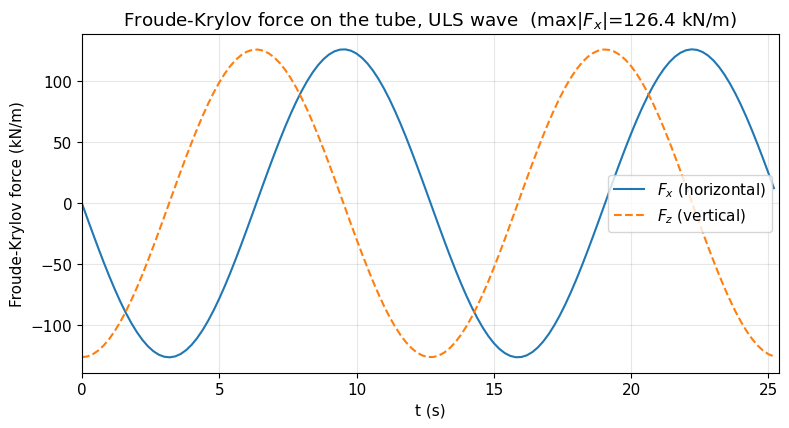

FK max|Fx|  (boundary integral, C_I = 1) = 126.4 kN/m
            with added mass (C_M = 2)     = 252.7 kN/m


In [6]:
tt = np.arange(0, 2*T_uls, 0.2)
F_t = np.array([calcForce(cyl, wv, ti) for ti in tt])    # N/m
Fx, Fz = F_t[:, 0]/1e3, F_t[:, 1]/1e3                    # kN/m

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(tt, Fx, label="$F_x$ (horizontal)")
ax.plot(tt, Fz, label="$F_z$ (vertical)", ls="--")
ax.set_xlabel("t (s)"); ax.set_ylabel("Froude-Krylov force (kN/m)")
ax.set_title(f"Froude-Krylov force on the tube, ULS wave  (max$|F_x|$={np.max(np.abs(Fx)):.1f} kN/m)")
ax.legend(); ax.set_xlim(0, 2*T_uls)
plt.show()

print(f"FK max|Fx|  (boundary integral, C_I = 1) = {np.max(np.abs(Fx)):.1f} kN/m")
print(f"            with added mass (C_M = 2)     = {2*np.max(np.abs(Fx)):.1f} kN/m")

### Verification against the small-body formula
For a section small compared with the wavelength the boundary integral reduces to
$F_{FK,i}\approx\rho_w\pi R^2\,\dot u_i$ evaluated at the centroid. The residual
shows how well the point-evaluation holds for this tube.

In [7]:
ax_t = np.array([wv.particleAccPoi(t, 0.0, z0)[0] for t in tt])
Fx_small = rhoW*A_sec*ax_t/1e3                            # rho * pi R^2 * a_x
err = np.max(np.abs(Fx_small - Fx))/np.max(np.abs(Fx))*100
print(f"Small-body  rho*pi*R^2*u_dot   vs   boundary integral:   max difference = {err:.3f} %")

Small-body  rho*pi*R^2*u_dot   vs   boundary integral:   max difference = 0.005 %


### Dynamic-pressure field and the twin-tube layout
Left: the full domain over one wavelength — the pressure decays strongly with
depth, so the tubes (at $z_0=-47.5$ m) sit well below the energetic surface zone.
Right: an equal-axis zoom showing the nearly uniform pressure gradient across each
tube, which is what justifies the point-evaluation of the Froude–Krylov force.

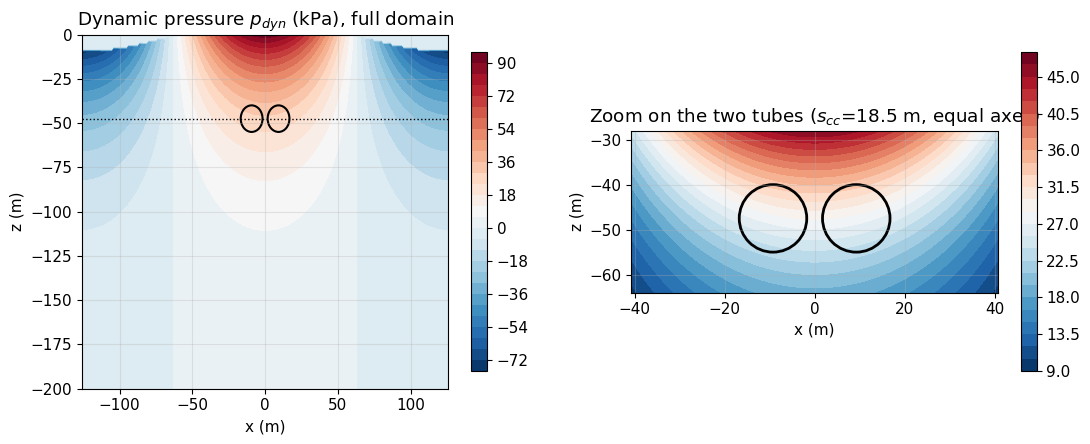

In [8]:
def pdyn_grid(xv, zv):
    P = np.zeros((zv.size, xv.size))
    for j, zz in enumerate(zv):
        for i, xx in enumerate(xv):
            P[j, i] = wv.pressureDynPoi(0.0, xx, zz)
    return P

fig, axs = plt.subplots(1, 2, figsize=(13, 4.6))
xv = np.linspace(-L_uls/2, L_uls/2, 200); zv = np.linspace(-d, 0, 150)
P = pdyn_grid(xv, zv)/1e3
cf = axs[0].contourf(xv, zv, P, levels=30, cmap="RdBu_r")
axs[0].axhline(z0, color="k", ls=":", lw=1)
axs[0].add_patch(plt.Circle((-s_cc/2, z0), R, fc="none", ec="k", lw=1.5))
axs[0].add_patch(plt.Circle((+s_cc/2, z0), R, fc="none", ec="k", lw=1.5))
axs[0].set_xlabel("x (m)"); axs[0].set_ylabel("z (m)")
axs[0].set_title("Dynamic pressure $p_{dyn}$ (kPa), full domain")
fig.colorbar(cf, ax=axs[0], shrink=0.9)

xz = np.linspace(-2.2*s_cc, 2.2*s_cc, 180); zz = np.linspace(z0-2.2*R, z0+2.6*R, 180)
Pz = pdyn_grid(xz, zz)/1e3
cf2 = axs[1].contourf(xz, zz, Pz, levels=30, cmap="RdBu_r")
axs[1].add_patch(plt.Circle((-s_cc/2, z0), R, fc="none", ec="k", lw=2))
axs[1].add_patch(plt.Circle((+s_cc/2, z0), R, fc="none", ec="k", lw=2))
axs[1].set_aspect("equal"); axs[1].set_xlabel("x (m)"); axs[1].set_ylabel("z (m)")
axs[1].set_title("Zoom on the two tubes ($s_{cc}$=18.5 m, equal axes)")
fig.colorbar(cf2, ax=axs[1], shrink=0.9)
plt.show()

## 3. Irregular sea: JONSWAP spectrum

The design sea state ($H_s=10.14$ m, $T_p=12.7$ s) is represented by a standard
JONSWAP spectrum with peak-enhancement factor $\gamma=3.3$. The spectrum is scaled
so that $4\sqrt{m_0}=H_s$ exactly ($m_0=\int S\,\mathrm d\omega$), then split into
harmonic components with random phase.

In [9]:
Hs, Tp = 10.14, 12.7
gamma  = 3.3
wp = 2*np.pi/Tp

def jonswap_omega(om):
    om = np.asarray(om, float); S = np.zeros_like(om); m = om > 0
    sig = np.where(om <= wp, 0.07, 0.09)
    r = np.exp(-((om - wp)**2)/(2*sig**2*wp**2))
    S[m] = (g**2/om[m]**5)*np.exp(-1.25*(wp/om[m])**4)*gamma**r[m]
    return S

w_grid = np.arange(0.0, 2.0, 2.0/256)
S = jonswap_omega(w_grid)
m0 = np.trapz(S, w_grid)
S *= (Hs/(4*np.sqrt(m0)))**2                              # exact Hs rescaling
print(f"JONSWAP rescaled so 4 sqrt(m0) = {4*np.sqrt(np.trapz(S, w_grid)):.3f} m   (target Hs = {Hs} m)")

mask = S > S.max()*1e-6
wc  = w_grid[mask]; dw = w_grid[1] - w_grid[0]
amp = np.sqrt(2*S[mask]*dw)
kc  = np.array([LinearWave2D(rhoW, g, d, 2*np.pi/wi, 1.0, msg=False).k for wi in wc])
print(f"{wc.size} wave components retained")

JONSWAP rescaled so 4 sqrt(m0) = 10.140 m   (target Hs = 10.14 m)
223 wave components retained


### Spectrum and a surface-elevation realisation

realised Hs = 10.16 m,   max|u| = 0.86 m/s


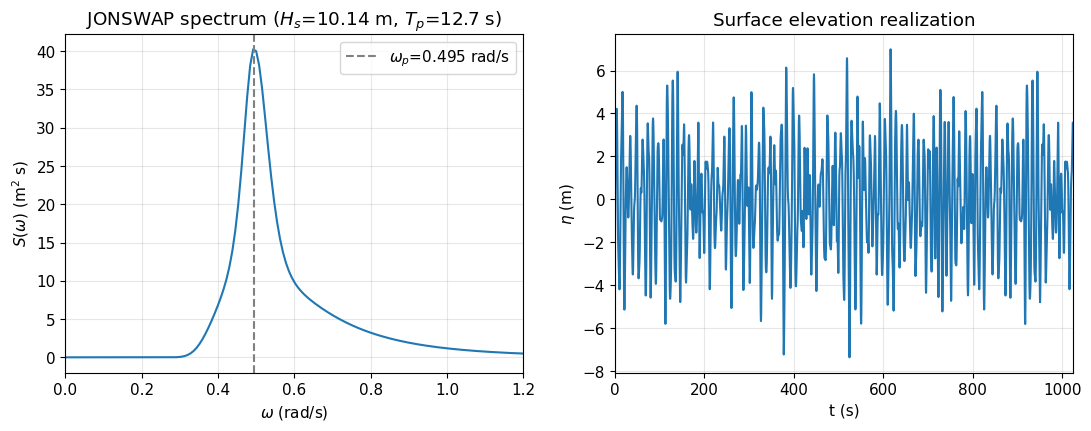

In [10]:
ts = np.arange(0, 1024.0, 0.2)
depthfac = np.cosh(kc*(d + z0))/np.sinh(kc*d)            # finite-depth velocity factor

def realize(seed):
    ph  = np.random.default_rng(seed).uniform(0, 2*np.pi, wc.size)
    pht = -np.outer(wc, ts) + ph[:, None]
    cos_, sin_ = np.cos(pht), np.sin(pht)
    eta = (amp[:, None]*cos_).sum(0)
    u   = ((amp*wc*depthfac)[:, None]*cos_).sum(0)
    a   = ((amp*wc**2*depthfac)[:, None]*sin_).sum(0)
    return eta, u, a

best = min(range(40), key=lambda s: abs(4*np.std(realize(s)[0]) - Hs))
eta, u, a = realize(best)
print(f"realised Hs = {4*np.std(eta):.2f} m,   max|u| = {np.max(np.abs(u)):.2f} m/s")

fig, axs = plt.subplots(1, 2, figsize=(13, 4.4))
axs[0].plot(w_grid, S)
axs[0].axvline(wp, color="grey", ls="--", label=f"$\\omega_p$={wp:.3f} rad/s")
axs[0].set_xlabel("$\\omega$ (rad/s)"); axs[0].set_ylabel("$S(\\omega)$ (m$^2$ s)")
axs[0].set_title(f"JONSWAP spectrum ($H_s$={Hs} m, $T_p$={Tp} s)")
axs[0].set_xlim(0, 1.2); axs[0].legend()
axs[1].plot(ts, eta)
axs[1].set_xlabel("t (s)"); axs[1].set_ylabel("$\\eta$ (m)")
axs[1].set_title("Surface elevation realization")
axs[1].set_xlim(0, ts.max())
plt.show()

## 4. Morison force in the design sea state

The in-line force per unit length on the tube is the Morison equation,
$$q(t) = \underbrace{\tfrac12\rho_w C_D D\,u|u|}_{\text{drag}}
        + \underbrace{\rho_w C_M (\pi R^2)\,\dot u}_{\text{inertia}},$$
with $C_D=1.0$ and $C_M=1+C_a=2.0$ (added mass $C_a=1$ for a circular cylinder).
At $KC=1.19$ the loading is inertia-dominated: the inertia and drag peaks occur a
quarter period apart, so the total peak is set by the inertia term (the drag is
near zero at that instant).

Morison peak:  inertia = 157.2 kN/m,  drag = 5.7 kN/m,  total = 157.2 kN/m


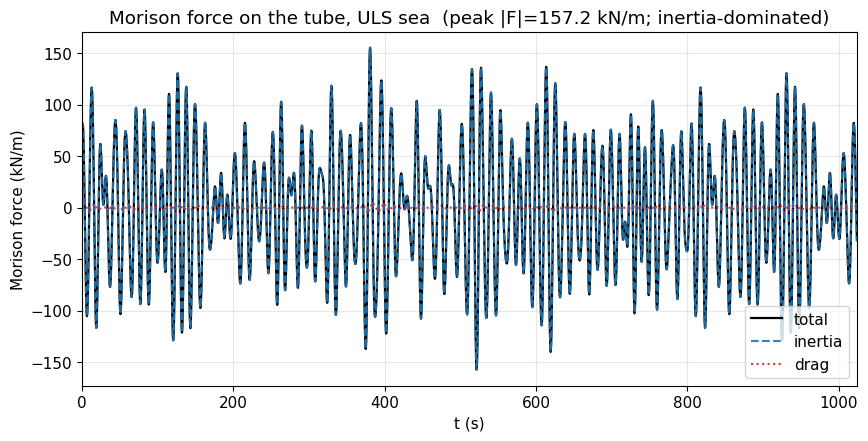

In [11]:
CD, CI = 1.0, 2.0
f_drag = 0.5*rhoW*CD*D*u*np.abs(u)/1e3                   # kN/m
f_iner = rhoW*CI*A_sec*a/1e3
f_tot  = f_drag + f_iner
print(f"Morison peak:  inertia = {np.max(np.abs(f_iner)):.1f} kN/m,  "
      f"drag = {np.max(np.abs(f_drag)):.1f} kN/m,  total = {np.max(np.abs(f_tot)):.1f} kN/m")

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(ts, f_tot,  label="total",   color="k", lw=1.6)
ax.plot(ts, f_iner, label="inertia", color="tab:blue", ls="--", alpha=0.9)
ax.plot(ts, f_drag, label="drag",    color="tab:red",  ls=":",  alpha=0.9)
ax.set_xlabel("t (s)"); ax.set_ylabel("Morison force (kN/m)")
ax.set_title(f"Morison force on the tube, ULS sea  (peak |F|={np.max(np.abs(f_tot)):.1f} kN/m; inertia-dominated)")
ax.legend(); ax.set_xlim(0, ts.max())
plt.show()

## Summary

| Quantity | Result |
|---|---|
| Wave regime | Morison, inertia-dominated ($\pi D/L=0.19$, $KC=1.19$) |
| Froude–Krylov force (per tube) | ~126 kN/m ($C_I=1$); ~253 kN/m with added mass |
| JONSWAP | $\gamma=3.3$, scaled to $H_s=10.14$ m |
| Morison peak force (per tube) | ~157 kN/m (inertia ~157, drag ~6) |

The wave load is **inertia-dominated**, so diffraction theory is unnecessary and
the boundary-integral Froude–Krylov force matches the small-body formula to within
a fraction of a percent. These per-tube loads are the dynamic inputs carried into
the structural and dynamic analyses.